## Scenario

Patient BMI is high →
Give diet plan →
Check again → repeat until BMI becomes normal

# Workflow
Start → Calculate BMI → Check
        -> if high → Diet → Loop back
        -> if normal → End

In [ ]:
#1: Define State
from typing import TypedDict

class HealthState(TypedDict):
    weight: float
    height: float
    bmi: float
    status: str

In [3]:
#2: Node → Calculate BMI

def calculate_bmi(state: HealthState) -> HealthState:
    state["bmi"] = state["weight"] / (state["height"] ** 2)
    return state

In [4]:
#3: Decision Function

def check_bmi(state: HealthState) -> str:
    if state["bmi"] >= 25:
        return "diet_node"
    else:
        return "end"

In [5]:
# 4: Diet Node (simulate weight loss)

def diet_plan(state: HealthState) -> HealthState:
    state["weight"] -= 2   # reduce weight each loop
    state["status"] = "Following diet plan"
    return state

In [9]:
# 5: Build Graph
from langgraph.graph import StateGraph, START, END

builder = StateGraph(HealthState)

builder.add_node("bmi_node", calculate_bmi)
builder.add_node("diet_node", diet_plan)

builder.add_edge(START, "bmi_node")

# Conditional loop
builder.add_conditional_edges(
    "bmi_node",
    check_bmi,
    {
        "diet_node": "diet_node",
        "end": END
    }
)

# Loop back
builder.add_edge("diet_node", "bmi_node")

graph = builder.compile()

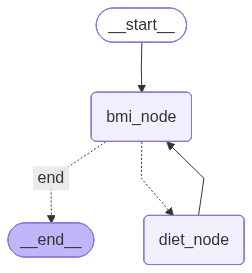

In [7]:
# 6: Visualize Graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
#7: Example

result = graph.invoke({
    "weight": 90,   # high weight
    "height": 1.7
})

print(result)

{'weight': 72, 'height': 1.7, 'bmi': 24.913494809688583, 'status': 'Following diet plan'}
